<a href="https://colab.research.google.com/github/JustmeLu/Tareas-automatizacionInicial/blob/main/2-Ejercicios/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Perceptrón
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Luisa Guerrero &bull; 2026-01
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos un perceptrón para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

---
## <font color='264CC7'> Clasificación </font>

Se usará el conjunto de datos de dígitos de MNIST.

In [2]:
# Cargamos el dataset MNIST
X, y = fetch_openml('mnist_784', return_X_y=True, parser='auto')


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [11]:


# Cargar datos
data = pd.read_csv("drug200.csv")

# Mostrar primeros registros
display(data.head())



,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [12]:
# Descripción
print(data.describe())


              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000


In [14]:
# One-Hot Encoding (variables categóricas)
data_encoded = pd.get_dummies(
    data,
    columns=["Sex", "BP", "Cholesterol"],
    drop_first=True
)

# Separar variables de entrada y salida
X = data_encoded.drop("Drug", axis=1)
y = data_encoded["Drug"]

# Estandarización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Codificar variable objetivo (multiclase)
classes, y_encoded = np.unique(y, return_inverse=True)

# Resultados finales
print("Clases:", classes)
print("Shape X_scaled:", X_scaled.shape)
print("Shape y_encoded:", y_encoded.shape)


Clases: ['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']
Shape X_scaled: (200, 6)
Shape y_encoded: (200,)



### <font color='264CC7'> Determinación de la red </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina una red neuronal para clasificar los datos:
<ul>
  <li>Define la red.</li>
  <li>Compila la red.</li>
  <li>Presenta un resumen de la red.</li>
</ul>
</div>


In [17]:
# Definir la red neuronal
model = Sequential([
    Dense(16, activation="relu", input_shape=(X_scaled.shape[1],)),
    Dense(8, activation="relu"),
    Dense(len(classes), activation="softmax")
])

# Compilar la red
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Resumen de la red
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.2577 - loss: 1.5447 - val_accuracy: 0.5938 - val_loss: 1.2684
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5870 - loss: 1.1895 - val_accuracy: 0.6250 - val_loss: 1.0970
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6459 - loss: 1.0149 - val_accuracy: 0.6875 - val_loss: 0.9053
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6869 - loss: 0.8619 - val_accuracy: 0.6875 - val_loss: 0.7337
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7829 - loss: 0.6602 - val_accuracy: 0.8438 - val_loss: 0.5704
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8920 - loss: 0.4940 - val_accuracy: 0.8750 - val_loss: 0.4335
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9223 - loss: 0.3417 - val_accuracy: 0.8750 - val_loss: 0.3456
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9253 - loss: 0.2622 - val_accuracy: 0.8750 - val_loss: 0.2875


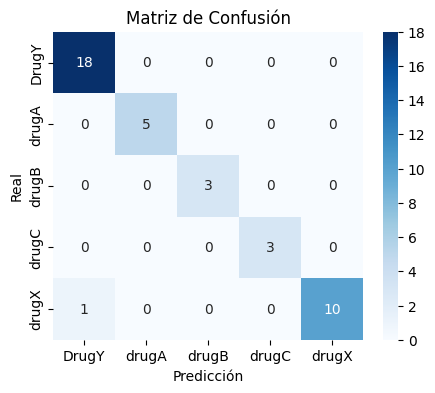

Reporte de clasificación:
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



In [19]:


# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Entrenar el modelo
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Evaluar el modelo con el conjunto de prueba
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss:.4f}")
print(f"Accuracy en test: {accuracy:.4f}")

# Predicciones
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# Métricas de evaluación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=classes))


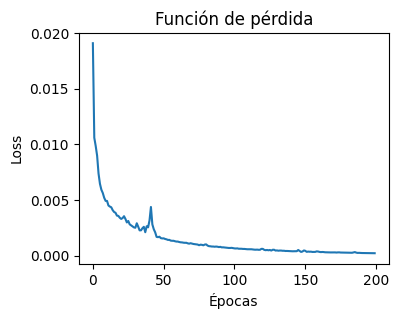

In [20]:

# Entrenamiento del modelo


history = model.fit(
    X_scaled,
    y_encoded,
    epochs=200,
    verbose=0
)

# Visualizar la evolución de la función de pérdida


import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.plot(history.history['loss'])
plt.title('Función de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()


El modelo tiene una buena convergencia de la función de perdida y alcanza una precisión del 97.5 % en el conjunto de prueba.Con clasificación perfecta en la mayoría de las clases y un pcoo de error en la clase DrugX.